# Figures 8 — Quantitative evaluation of Noise Robustness — ML-FTLE vs Poincaré-FTLE (JSD · SSIM · HDF · IOU)against QR-FTLE

## This notebook reproduces the manuscript's **quantitative performance analysis** for the predictive and geometry-guided FTLE proxies, corresponding to **Fig. 8**.

| Stage             | What happens                                                                                                                      |
| ----------------- | --------------------------------------------------------------------------------------------------------------------------------- |
| **ML-FTLE**       | Computed independently on each noisy signal realisation                                                                           |
| **Poincaré PLSR** | Computed independently on the same noisy signal, **calibrated (β̂ fitted) against that trial's own ML-FTLE**, evaluated vs QR-FTLE |
| **Trials**        | Equal number of trials at every SNR, including clean (σ = 0), for consistent aggregation                                          |
| **Aggregation**   | Mean ± std across trials → `noise_robustness_results.csv`; raw rows → `noise_robustness_raw.csv`                                  |
| **Plots**         | Mean line + ±1 σ shaded band; clean baseline column/row marked green                                                              |

**Why this is correct:** every Poincaré estimator at a given SNR sees and is calibrated on the same noise realisation as ML-FTLE. Neither uses the clean signal as an oracle. Final metric evaluation is always vs QR-FTLE.

**Metrics** (boundary τ = `LLE_THRESH`, not zero):

| Metric         | Measures                                       |
| -------------- | ---------------------------------------------- |
| Spearman ρ     | Rank-order monotonic agreement with QR-FTLE    |
| MCC            | Binary chaotic/periodic classification quality |
| Sign Agreement | Per-window regime identification fraction      |

**Re-run guide:** `c01→c02→c03→c04→c05` to recompute; `c01→c02→c03→c06→c07→c08→c09→c10` to replot only.


In [1]:
import warnings, time, builtins
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr
from scipy.ndimage import median_filter
from sklearn.metrics import matthews_corrcoef
warnings.filterwarnings('ignore')
print('Imports OK')


Imports OK


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CONFIG  — edit then re-run to recompute
# ════════════════════════════════════════════════════════════════════════════
from parameters import discover_all_params
PARAM_SETS = discover_all_params()

# SNR levels.  float('inf') = clean (σ = 0) — ALWAYS first.
SNR_DB_LEVELS = [float('inf'),100,80,60,40,20,10,5,0]

N_TRIALS = 30       # independent noise realisations per noisy SNR level
                      # (clean uses 1 trial — σ = 0 is deterministic)

CLEAN_SENTINEL = 110  # numeric x-value for ∞ dB on plots
CLEAN_LABEL    = '∞ dB'

POINCARE_METHODS_ALL = ['JSD', 'SSIM', 'HDF', 'IOU']
ALL_METHODS = ['ML-FTLE'] + [f'PLSR-{m}' for m in POINCARE_METHODS_ALL]

METHOD_COLORS = {
    'ML-FTLE'  : '#d62728',
    'JSD' : '#1f77b4',
    'SSIM': '#2ca02c',
    'HDF' : '#ff7f0e',
    'IOU' : '#9467bd',
    'QR-FTLE'  : 'black',
}


FIGURE_DIR  = Path('data/noise_robustness')
RAW_CSV     = Path(FIGURE_DIR/'noise_robustness_raw.csv')
RESULTS_CSV = Path(FIGURE_DIR/'noise_robustness_results.csv')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def snr_label(snr):
    return CLEAN_LABEL if np.isinf(snr) else f'{snr:+.0f} dB'

def snr_plot_val(snr):
    return CLEAN_SENTINEL if np.isinf(snr) else float(snr)

print(f'Datasets     : {list(PARAM_SETS.keys())}')
print(f'SNR dB levels: {[snr_label(s) for s in SNR_DB_LEVELS]}')
print(f'Trials/SNR   : {N_TRIALS} (noisy), 1 (clean)')
print(f'Methods      : {ALL_METHODS}')


Discovered 3 parameter file(s) in  parameters:
  ✓  data_1.py  →  OUT_DIR= data/data_1
  ✓  data_2.py  →  OUT_DIR= data/data_2
  ✓  data_3.py  →  OUT_DIR= data/data_3
Datasets     : ['data_1', 'data_2', 'data_3']
SNR dB levels: ['∞ dB', '+100 dB', '+80 dB', '+60 dB', '+40 dB', '+20 dB', '+10 dB', '+5 dB', '+0 dB']
Trials/SNR   : 30 (noisy), 1 (clean)
Methods      : ['ML-FTLE', 'PLSR-JSD', 'PLSR-SSIM', 'PLSR-HDF', 'PLSR-IOU']


════════════════════════════════════════════════════════════════════════════

- BASELINE — load QR-FTLE ground truth + clean signal per dataset
- QR reference is median-smoothed with the same window used for ML-FTLE output
- to avoid asymmetric smoothing bias in the noise-robustness metrics

════════════════════════════════════════════════════════════════════════════


In [ ]:

def load_signal(P):
    df = pd.read_csv(P.ODE_CSV)
    t = df.iloc[:, 0].values.astype(float)
    x = df.iloc[:, 1].values.astype(float)
    dt = float(np.median(np.diff(t)))
    return t, x, dt

def load_qr(P):
    for name in ('qr_ftle.csv', 'qr.csv', 'ftle_qr.csv'):
        p = P.OUT_DIR / name
        if not p.exists():
            continue
        df = pd.read_csv(p)
        if 'time' not in df.columns:
            print(f' ⚠ "time" column missing in {p.name}. Cols: {list(df.columns)}')
            return None, None
        if 'lam1_qr_smooth' in df.columns:
            lam_col = 'lam1_qr_smooth'
        else:
            fb = [c for c in ('lam1_qr', 'lam2_qr', 'lam3_qr') if c in df.columns]
            if fb:
                lam_col = fb[0]
                print(f' ⚠ "lam1_qr_smooth" missing — using "{lam_col}"')
            else:
                print(f' ⚠ No λ column in {p.name}. Cols: {list(df.columns)}')
                return None, None
        return df['time'].values.astype(float), df[lam_col].values.astype(float)
    print(f' ⚠ No QR-FTLE CSV found in {P.OUT_DIR}')
    return None, None

baselines = {}
for did, P in PARAM_SETS.items():
    t_sig, signal, dt = load_signal(P)
    t_qr, lam_qr_raw = load_qr(P)
    if lam_qr_raw is None:
        continue
    lam_qr = median_filter(lam_qr_raw, size=max(3, int(P.SMOOTH_WINDOW)), mode='nearest')
    baselines[did] = dict(P=P, t_sig=t_sig, signal=signal, dt=dt,
                          t_qr=t_qr, lam_qr=lam_qr, lam_qr_raw=lam_qr_raw)
    print(f' {did}: signal={len(signal)} pts QR={len(lam_qr)} pts '
          f'LLE_THRESH={P.LLE_THRESH} SMOOTH_WINDOW={P.SMOOTH_WINDOW}')
print(f'✓ {len(baselines)} dataset(s) ready.')


 data_1: signal=6001 pts QR=189 pts LLE_THRESH=0.005 SMOOTH_WINDOW=20
 data_2: signal=6001 pts QR=56 pts LLE_THRESH=0.005 SMOOTH_WINDOW=20
 data_3: signal=8001 pts QR=259 pts LLE_THRESH=0.005 SMOOTH_WINDOW=30
✓ 3 dataset(s) ready.


## COMPUTE — multi-trial noise sweep (run once; saves two CSVs)

#

For each (dataset, SNR, trial):

1.  Draw an independent AWGN realisation → sig_noisy
2.  Run ML-FTLE on sig_noisy → (t_ml, lam_ml)
3.  Run Poincaré PLSR on sig_noisy, calibrated against lam_ml of THIS trial
    → proxy evaluated on t_qr
4.  Compute ρ / MCC / SA / Sensitivity / Specificity against the smoothed QR-FTLE reference

###

Fixes in this version:

• Equal trial counts for clean and noisy SNR levels

• Symmetric median smoothing of QR-FTLE and ML-FTLE outputs

• MCC / Sign Agreement use z-normalised thresholding at 0

• Near-constant estimates are rejected to avoid spurious high ρ values


In [ ]:
from core.ml_ftle import ftle_for_window
from core.poincare_ftle import poincare_proxy_series

def snr_to_noise_std(signal, snr_db):
    if np.isinf(snr_db):
        return 0.0
    signal_rms = np.sqrt(np.mean(signal**2))
    return signal_rms / (10 ** (snr_db / 20.0))

def add_awgn(signal, snr_db, rng):
    sigma = snr_to_noise_std(signal, snr_db)
    if sigma == 0.0:
        return signal.copy()
    return signal + rng.normal(0.0, sigma, size=signal.shape)

def push_builtins(P):
    for k, v in dict(
        EMB_DIM=P.EMB_DIM, TAU=P.POINCARE_LAG, POINCARE_LAG=P.POINCARE_LAG,
        KNN_NEIGH=P.KNN_NEIGH, H_FTLE_MAX=P.H_FTLE_MAX, HORIZON_MAX=P.H_FTLE_MAX,
        TEST_RATIO=getattr(P, 'TEST_RATIO', 0.30), LLE_THRESH=P.LLE_THRESH,
        ODE_CSV=P.ODE_CSV, OUT_DIR=P.OUT_DIR,
        T_WINDOW_STEPS=P.T_WINDOW_STEPS, T_STEP=P.T_STEP,
        BINS=P.BINS, CONNECT_LINES=P.CONNECT_LINES,
        NN_POINCARE=P.NN_POINCARE,
        MIN_REL_SEPARATION_PCT=P.MIN_REL_SEPARATION_PCT,
    ).items():
        setattr(builtins, k, v)

def run_ml_ftle_on(sig_noisy, t_sig, dt, P):
    push_builtins(P)
    L, step = P.T_WINDOW_STEPS, P.T_STEP
    idx = np.arange(0, len(t_sig) - L + 1, step, dtype=int)
    tc = t_sig[idx + L // 2]
    rows = []
    for s, center in zip(idx, tc):
        seg = sig_noisy[s: s + L]
        fv, _, _, _ = ftle_for_window(seg, dt, m=P.EMB_DIM,
                                      k_neighbors=P.KNN_NEIGH,
                                      H_ftle=P.H_FTLE_MAX)
        rows.append({'time': float(center),
                     'ftle': float(fv) if np.isfinite(fv) else 0.0})
    df = pd.DataFrame(rows)
    df['ftle_smooth'] = df['ftle'].rolling(
        P.SMOOTH_WINDOW, center=True, min_periods=5).median()
    return df

def compute_metrics(t_est, lam_est, t_ref, lam_ref):
 EPS = 1e-12
 lam_i = np.interp(t_ref, t_est, lam_est)
 mask = np.isfinite(lam_i) & np.isfinite(lam_ref)
 if mask.sum() < 5:
  return dict(rho=np.nan, mcc=np.nan, sign_agree=np.nan,
              sensitivity=np.nan, specificity=np.nan)
 li, lr = lam_i[mask], lam_ref[mask]
 if np.nanstd(li) < 1e-10:
  return dict(rho=np.nan, mcc=np.nan, sign_agree=np.nan,
              sensitivity=np.nan, specificity=np.nan)

 rho, _ = spearmanr(li, lr)

 li_z = (li - np.nanmean(li)) / (np.nanstd(li) + EPS)
 lr_z = (lr - np.nanmean(lr)) / (np.nanstd(lr) + EPS)
 y_est = (li_z > P.LLE_THRESH).astype(int)
 y_ref = (lr_z > P.LLE_THRESH).astype(int)

 try:
  mcc = matthews_corrcoef(y_ref, y_est)
 except Exception:
  mcc = np.nan

 sign_agree = float(np.mean(y_est == y_ref))
 tp = np.sum((y_ref == 1) & (y_est == 1))
 fn = np.sum((y_ref == 1) & (y_est == 0))
 tn = np.sum((y_ref == 0) & (y_est == 0))
 fp = np.sum((y_ref == 0) & (y_est == 1))
 sensitivity = float(tp / (tp + fn)) if (tp + fn) > 0 else np.nan
 specificity = float(tn / (tn + fp)) if (tn + fp) > 0 else np.nan

 return dict(rho=float(rho), mcc=float(mcc), sign_agree=sign_agree,
             sensitivity=sensitivity, specificity=specificity)

all_records = []
all_traces = {}
rng = np.random.default_rng(42)

for did, B in baselines.items():
    P, t_sig, signal, dt = B['P'], B['t_sig'], B['signal'], B['dt']
    t_qr, lam_qr = B['t_qr'], B['lam_qr']
    push_builtins(P)

    for snr_db in SNR_DB_LEVELS:
        n_trials = N_TRIALS
        noise_std = snr_to_noise_std(signal, snr_db)
        tag = 'CLEAN' if np.isinf(snr_db) else f'{snr_db:+.0f} dB'
        print(f' {did} SNR={tag:<12} σ={noise_std:.4f} ({n_trials} trial(s))', end=' ')
        t0 = time.time()

        ml_lams = []
        poinc_lams = {m: [] for m in POINCARE_METHODS_ALL}

        for trial in range(n_trials):
            sig_noisy = add_awgn(signal, snr_db, rng)

            df_ml = run_ml_ftle_on(sig_noisy, t_sig, dt, P)
            t_ml = df_ml['time'].values
            lam_ml = df_ml['ftle_smooth'].fillna(0).values
            m_ml = compute_metrics(t_ml, lam_ml, t_qr, lam_qr)
            all_records.append(dict(dataset=did, snr_db=snr_db, trial=trial,
                                    method='ML-FTLE', **m_ml))
            ml_lams.append((t_ml, lam_ml))

            try:
                poinc = poincare_proxy_series(
                    signal=sig_noisy,
                    tsig=t_sig,
                    lam_ml=lam_ml,
                    tml=t_ml,
                    tref=t_qr,
                    window=P.T_WINDOW_STEPS,
                    step=P.T_STEP,
                    methods=POINCARE_METHODS_ALL,
                    bins=P.BINS,
                    lag=P.POINCARE_LAG,
                    connect_lines=P.CONNECT_LINES,
                    nn=P.NN_POINCARE,
                    min_rel_sep_pct=P.MIN_REL_SEPARATION_PCT,
                    regressor='plsr',
                    n_components=1,
                )
                for mth, (centers, proxy_on_tref) in poinc.items():
                    m_p = compute_metrics(t_qr, proxy_on_tref, t_qr, lam_qr)
                    all_records.append(dict(dataset=did, snr_db=snr_db, trial=trial,
                                            method=f'PLSR-{mth}', **m_p))
                    poinc_lams[mth].append((t_qr, proxy_on_tref))
            except Exception as ex:
                if trial == 0:
                    print(f'[Poincaré: {ex}]', end=' ')
                for mth in POINCARE_METHODS_ALL:
                    all_records.append(dict(dataset=did, snr_db=snr_db, trial=trial,
                                            method=f'PLSR-{mth}',
                                            rho=np.nan, mcc=np.nan, sign_agree=np.nan, sensitivity=np.nan, specificity=np.nan))

        t_ml_ref = ml_lams[0][0]
        lam_ml_mean = np.nanmean([np.interp(t_ml_ref, t, l) for t, l in ml_lams], axis=0)
        all_traces[(did, snr_db, 'ML-FTLE')] = (t_ml_ref, lam_ml_mean)

        for mth in POINCARE_METHODS_ALL:
            valid = [(t, p) for t, p in poinc_lams[mth] if p is not None]
            if valid:
                proxy_mean = np.nanmean([np.interp(t_qr, t, p) for t, p in valid], axis=0)
                all_traces[(did, snr_db, f'PLSR-{mth}')] = (t_qr, proxy_mean)

        ml_rhos = [r['rho'] for r in all_records
                   if r['dataset'] == did and r['snr_db'] == snr_db and r['method'] == 'ML-FTLE']
        ml_mccs = [r['mcc'] for r in all_records
                   if r['dataset'] == did and r['snr_db'] == snr_db and r['method'] == 'ML-FTLE']
        ml_sas = [r['sign_agree'] for r in all_records
                  if r['dataset'] == did and r['snr_db'] == snr_db and r['method'] == 'ML-FTLE']
        rho_m = np.nanmean(ml_rhos); rho_s = np.nanstd(ml_rhos)
        mcc_m = np.nanmean(ml_mccs); sa_m = np.nanmean(ml_sas)
        std_str = f'±{rho_s:.3f}' if n_trials > 1 else ''
        print(f'ML: ρ={rho_m:.3f}{std_str} MCC={mcc_m:.3f} SA={sa_m:.3f} '
              f'NN_POINCARE={P.NN_POINCARE} [{time.time()-t0:.1f}s]')

print('✓ Compute complete.')



 data_1 SNR=CLEAN        σ=0.0000 (30 trial(s)) ML: ρ=0.813±0.000 MCC=0.968 SA=0.984 NN_POINCARE=6 [408.1s]
 data_1 SNR=+100 dB      σ=0.0000 (30 trial(s)) ML: ρ=0.813±0.037 MCC=0.968 SA=0.984 NN_POINCARE=6 [405.4s]
 data_1 SNR=+80 dB       σ=0.0000 (30 trial(s)) ML: ρ=0.836±0.045 MCC=0.968 SA=0.984 NN_POINCARE=6 [405.9s]
 data_1 SNR=+60 dB       σ=0.0002 (30 trial(s)) ML: ρ=0.919±0.014 MCC=0.968 SA=0.984 NN_POINCARE=6 [411.7s]
 data_1 SNR=+40 dB       σ=0.0024 (30 trial(s)) ML: ρ=0.866±0.052 MCC=0.971 SA=0.986 NN_POINCARE=6 [421.3s]
 data_1 SNR=+20 dB       σ=0.0244 (30 trial(s)) ML: ρ=0.753±0.078 MCC=0.972 SA=0.987 NN_POINCARE=6 [444.6s]
 data_1 SNR=+10 dB       σ=0.0771 (30 trial(s)) ML: ρ=0.714±0.051 MCC=0.823 SA=0.910 NN_POINCARE=6 [460.1s]
 data_1 SNR=+5 dB        σ=0.1371 (30 trial(s)) ML: ρ=0.726±0.069 MCC=0.318 SA=0.666 NN_POINCARE=6 [476.4s]
 data_1 SNR=+0 dB        σ=0.2438 (30 trial(s)) ML: ρ=0.548±0.189 MCC=0.000 SA=0.598 NN_POINCARE=6 [480.3s]
 data_2 SNR=CLEAN        σ=

════════════════════════════════════════════════════════════════════════════

### SAVE — two CSVs

- noise_robustness_raw.csv : one row per (dataset, snr_db, trial, method)
- noise_robustness_results.csv : mean ± std across trials per (dataset, snr_db, method)
  ════════════════════════════════════════════════════════════════════════════


In [ ]:

raw_df = pd.DataFrame(all_records)
raw_df.to_csv(RAW_CSV, index=False)
print(f'Raw rows: {len(raw_df)} → {RAW_CSV}')

# Aggregate mean ± std across trials
agg = (raw_df.groupby(['dataset', 'snr_db', 'method'])
 .agg(
 rho = ('rho', 'mean'),
 rho_std = ('rho', 'std'),
 mcc = ('mcc', 'mean'),
 mcc_std = ('mcc', 'std'),
 sign_agree = ('sign_agree', 'mean'),
 sa_std = ('sign_agree', 'std'),
 sensitivity = ('sensitivity', 'mean'),
 sensitivity_std = ('sensitivity', 'std'),
 specificity = ('specificity', 'mean'),
 specificity_std = ('specificity', 'std'),
 n_trials = ('trial', 'count'),
 )
 .reset_index())
# std is NaN when n_trials=1 (clean) — replace with 0
for col in ('rho_std', 'mcc_std', 'sa_std', 'sensitivity_std', 'specificity_std'):
 agg[col] = agg[col].fillna(0.0)

agg.to_csv(RESULTS_CSV, index=False)
print(f'Agg rows: {len(agg)} → {RESULTS_CSV}')
print()
print(agg.groupby(['dataset', 'method'])[['rho', 'rho_std', 'mcc', 'sign_agree']]
      .mean().round(4))


Raw rows: 4050 → data/noise_robustness/noise_robustness_raw.csv
Agg rows: 135 → data/noise_robustness/noise_robustness_results.csv

                      rho  ...  sign_agree
dataset method             ...
data_1  ML-FTLE    0.7767  ...      0.8981
        PLSR-HDF   0.7494  ...      0.8682
        PLSR-IOU   0.7930  ...      0.8658
        PLSR-JSD   0.7848  ...      0.8693
        PLSR-SSIM  0.7896  ...      0.8737
data_2  ML-FTLE    0.6422  ...      0.8666
        PLSR-HDF   0.6472  ...      0.7687
        PLSR-IOU   0.6579  ...      0.8077
        PLSR-JSD   0.6535  ...      0.7998
        PLSR-SSIM  0.6596  ...      0.8149
data_3  ML-FTLE    0.5983  ...      0.7917
        PLSR-HDF   0.6926  ...      0.7934
        PLSR-IOU   0.6565  ...      0.7968
        PLSR-JSD   0.6498  ...      0.7960
        PLSR-SSIM  0.6619  ...      0.7964

[15 rows x 4 columns]


In [6]:
# ════════════════════════════════════════════════════════════════════════════
# LOAD — start here when replotting without recomputing
# ════════════════════════════════════════════════════════════════════════════
results_df     = pd.read_csv(RESULTS_CSV)
DATASETS_AVAIL = results_df['dataset'].unique().tolist()
METHODS_AVAIL  = results_df['method'].unique().tolist()
SNR_AVAIL = sorted(results_df['snr_db'].unique(),
                   key=lambda x: float('inf') if np.isinf(x) else -x)

METRICS = [
 ('rho', 'rho_std', r'Spearman $\rho$', (0.5, 1.0)),
 ('mcc', 'mcc_std', 'MCC', (0.5, 1.05)),
 ('sign_agree', 'sa_std', 'Sign Agreement', (0.75, 1.05)),
 ('sensitivity', 'sensitivity_std', 'Sensitivity (Recall)', (0.0, 1.05)),
 ('specificity', 'specificity_std', 'Specificity', (0.0, 1.05)),
]

print(f'Loaded {len(results_df)} aggregated rows')
print(f'  Datasets : {DATASETS_AVAIL}')
print(f'  Methods  : {METHODS_AVAIL}')
print(f'  SNR axis : {[snr_label(s) for s in SNR_AVAIL]}')
print(f'  Max n_trials: {int(results_df["n_trials"].max())}')


Loaded 135 aggregated rows
  Datasets : ['data_1', 'data_2', 'data_3']
  Methods  : ['ML-FTLE', 'PLSR-HDF', 'PLSR-IOU', 'PLSR-JSD', 'PLSR-SSIM']
  SNR axis : ['+100 dB', '+80 dB', '+60 dB', '+40 dB', '+20 dB', '+10 dB', '+5 dB', '+0 dB', '∞ dB']
  Max n_trials: 30


## PLOT — FTLE time series (mean trace across trials)

════════════════════════════════════════════════════════════════════════════
Layout: one row per SNR level (clean → noisiest)

• Clean row: green background

• Noisy rows: thin dashed overlay of clean mean trace
════════════════════════════════════════════════════════════════════════════


In [ ]:

for did, B in baselines.items():
    t_qr, lam_qr = B['t_qr'], B['lam_qr']
    LT  = B['P'].LLE_THRESH
    present = [m for m in ALL_METHODS
               if any((did, s, m) in all_traces for s in SNR_AVAIL)]

    n_rows = len(SNR_AVAIL)
    fig, axes = plt.subplots(n_rows, 1, figsize=(14, 3.0 * n_rows), sharex=True)
    if n_rows == 1:
        axes = [axes]
    fig.suptitle(
        f'FTLE Time Series — Noise Robustness  [{did}]  (mean of {N_TRIALS} trials)\n'
        'Dashed thin = clean-signal baseline overlay',
        fontsize=13, fontweight='bold')

    clean_snr    = float('inf')
    clean_traces = {m: all_traces.get((did, clean_snr, m)) for m in present}

    for row_i, snr in enumerate(SNR_AVAIL):
        ax       = axes[row_i]
        is_clean = np.isinf(snr)
        if is_clean:
            ax.set_facecolor('#f0fff4')

        ax.plot(t_qr, lam_qr, color='black', lw=2.2, alpha=0.70,
                zorder=6, label='QR-FTLE (ground truth)')
        ax.axhline(LT, color='gray', lw=0.8, ls=':', zorder=2,
                   label=f'LLE_THRESH={LT}')
        ax.axhline(0, color='black', lw=0.5, ls='--', alpha=0.35, zorder=1)

        for meth in present:
            col = METHOD_COLORS.get(meth, '#888')
            key = (did, snr, meth)
            if key in all_traces:
                t_e, lam_e = all_traces[key]
                ax.plot(t_e, lam_e, color=col,
                        lw=2.0 if is_clean else 1.4,
                        alpha=0.88, zorder=4, label=meth)
            if not is_clean and clean_traces.get(meth) is not None:
                t_c, lam_c = clean_traces[meth]
                ax.plot(t_c, lam_c, color=col, lw=0.85,
                        alpha=0.40, ls='--', zorder=3)

        n_t = 1 if is_clean else N_TRIALS
        title_str = (
            f'No Noise — Clean Baseline  (σ = 0)'
            if is_clean else
            f'SNR = {snr:+.0f} dB  '
            f'(σ = {snr_to_noise_std(B["signal"], snr):.3f}·std,  '
            f'{n_t} trial{"s" if n_t>1 else ""} averaged)')
        ax.set_title(title_str, fontsize=9.5,
                     color='#1a6b2e' if is_clean else 'black',
                     fontweight='bold' if is_clean else 'normal')
        ax.set_ylabel(r'$\hat{\lambda}$', fontsize=11)
        ax.grid(True, alpha=0.20, ls='--')
        if row_i == 0:
            ax.legend(fontsize=8, ncol=3, loc='upper right')

    axes[-1].set_xlabel('Time', fontsize=12)
    plt.tight_layout()
    out = FIGURE_DIR / f'{did}_ftle_timeseries_snr.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show(); plt.close(fig)
    print(f'  Saved → {out}')
print('\n✓ FTLE time-series done.')


  Saved → data/noise_robustness/data_1_ftle_timeseries_snr.png
  Saved → data/noise_robustness/data_2_ftle_timeseries_snr.png
  Saved → data/noise_robustness/data_3_ftle_timeseries_snr.png

✓ FTLE time-series done.


### PLOT — Metric vs SNR (mean ± 1σ shaded band)


In [ ]:

for did in DATASETS_AVAIL:
    sub = results_df[results_df['dataset'] == did]

    finite_snrs = sorted([s for s in SNR_AVAIL if not np.isinf(s)], reverse=True)
    tick_vals   = [CLEAN_SENTINEL] + finite_snrs
    tick_labels = [CLEAN_LABEL]   + [f'{int(s)} dB' for s in finite_snrs]

    for metric, std_col, ylabel, ylim in METRICS:
        fig, ax = plt.subplots(figsize=(15, 8))
       # ax.set_title(f'{ylabel} vs SNR  [{did}]  (mean ± 1σ, {N_TRIALS} trials)',fontsize=14, fontweight='bold', pad=12)

        for meth in [m for m in ALL_METHODS if m in METHODS_AVAIL]:
            row_m = (sub[sub['method'] == meth]
                     .sort_values('snr_db',
                                  key=lambda c: c.map(snr_plot_val),
                                  ascending=False))
            x_vals  = row_m['snr_db'].map(snr_plot_val).values
            y_vals  = row_m[metric].values
            y_err   = row_m[std_col].values
            col     = METHOD_COLORS.get(meth, '#888')
            c_mask  = np.array([np.isinf(v) for v in row_m['snr_db']])

            # Mean line
            ax.plot(x_vals, y_vals, marker='o', ms=5, lw=1.8,
                    color=col, alpha=0.90, label=meth, zorder=4)

            """
             # ±1σ shaded band (only where n_trials > 1)
            has_std = row_m['n_trials'].values > 1
            if has_std.any():
                xb = x_vals[has_std]; yb = y_vals[has_std]; eb = y_err[has_std]
                ax.fill_between(xb, yb - eb, yb + eb,color=col, alpha=0.12, zorder=2)
             """
            
            # Star on clean point
            if c_mask.any():
                ax.scatter(x_vals[c_mask], y_vals[c_mask],
                           marker='*', s=240, color=col, zorder=6,
                           edgecolors='black', linewidths=0.6)

        ax.axvline(CLEAN_SENTINEL, color='#1a6b2e', lw=1.2, ls='--',
                   alpha=0.7, zorder=1, label='Clean (∞ dB) baseline')
        ax.set_ylim(*ylim)
        ax.set_ylabel(ylabel, fontsize=28)
        #ax.set_xlabel('SNR  [← cleaner      noisier →]', fontsize=22)
        ax.grid(True, alpha=0.25, ls='--')
        ax.legend(fontsize=16, framealpha=0.9)
        ax.set_xticks(tick_vals)
        ax.set_xticklabels(tick_labels, fontsize=18, rotation=40, ha='right')
        ax.tick_params(axis='y', labelsize=22)
        ax.invert_xaxis()

        plt.tight_layout()
        out = FIGURE_DIR / f'{did}_{metric}_vs_snr_lineplot.png'
        plt.savefig(out, dpi=600, bbox_inches='tight')
        plt.show(); plt.close(fig)
        print(f'  Saved → {out}')

print('\n✓ Line plots done.')


  Saved → data/noise_robustness/data_1_rho_vs_snr_lineplot.png
  Saved → data/noise_robustness/data_1_mcc_vs_snr_lineplot.png
  Saved → data/noise_robustness/data_1_sign_agree_vs_snr_lineplot.png
  Saved → data/noise_robustness/data_1_sensitivity_vs_snr_lineplot.png
  Saved → data/noise_robustness/data_1_specificity_vs_snr_lineplot.png
  Saved → data/noise_robustness/data_2_rho_vs_snr_lineplot.png
  Saved → data/noise_robustness/data_2_mcc_vs_snr_lineplot.png
  Saved → data/noise_robustness/data_2_sign_agree_vs_snr_lineplot.png
  Saved → data/noise_robustness/data_2_sensitivity_vs_snr_lineplot.png
  Saved → data/noise_robustness/data_2_specificity_vs_snr_lineplot.png
  Saved → data/noise_robustness/data_3_rho_vs_snr_lineplot.png
  Saved → data/noise_robustness/data_3_mcc_vs_snr_lineplot.png
  Saved → data/noise_robustness/data_3_sign_agree_vs_snr_lineplot.png
  Saved → data/noise_robustness/data_3_sensitivity_vs_snr_lineplot.png
  Saved → data/noise_robustness/data_3_specificity_vs_snr

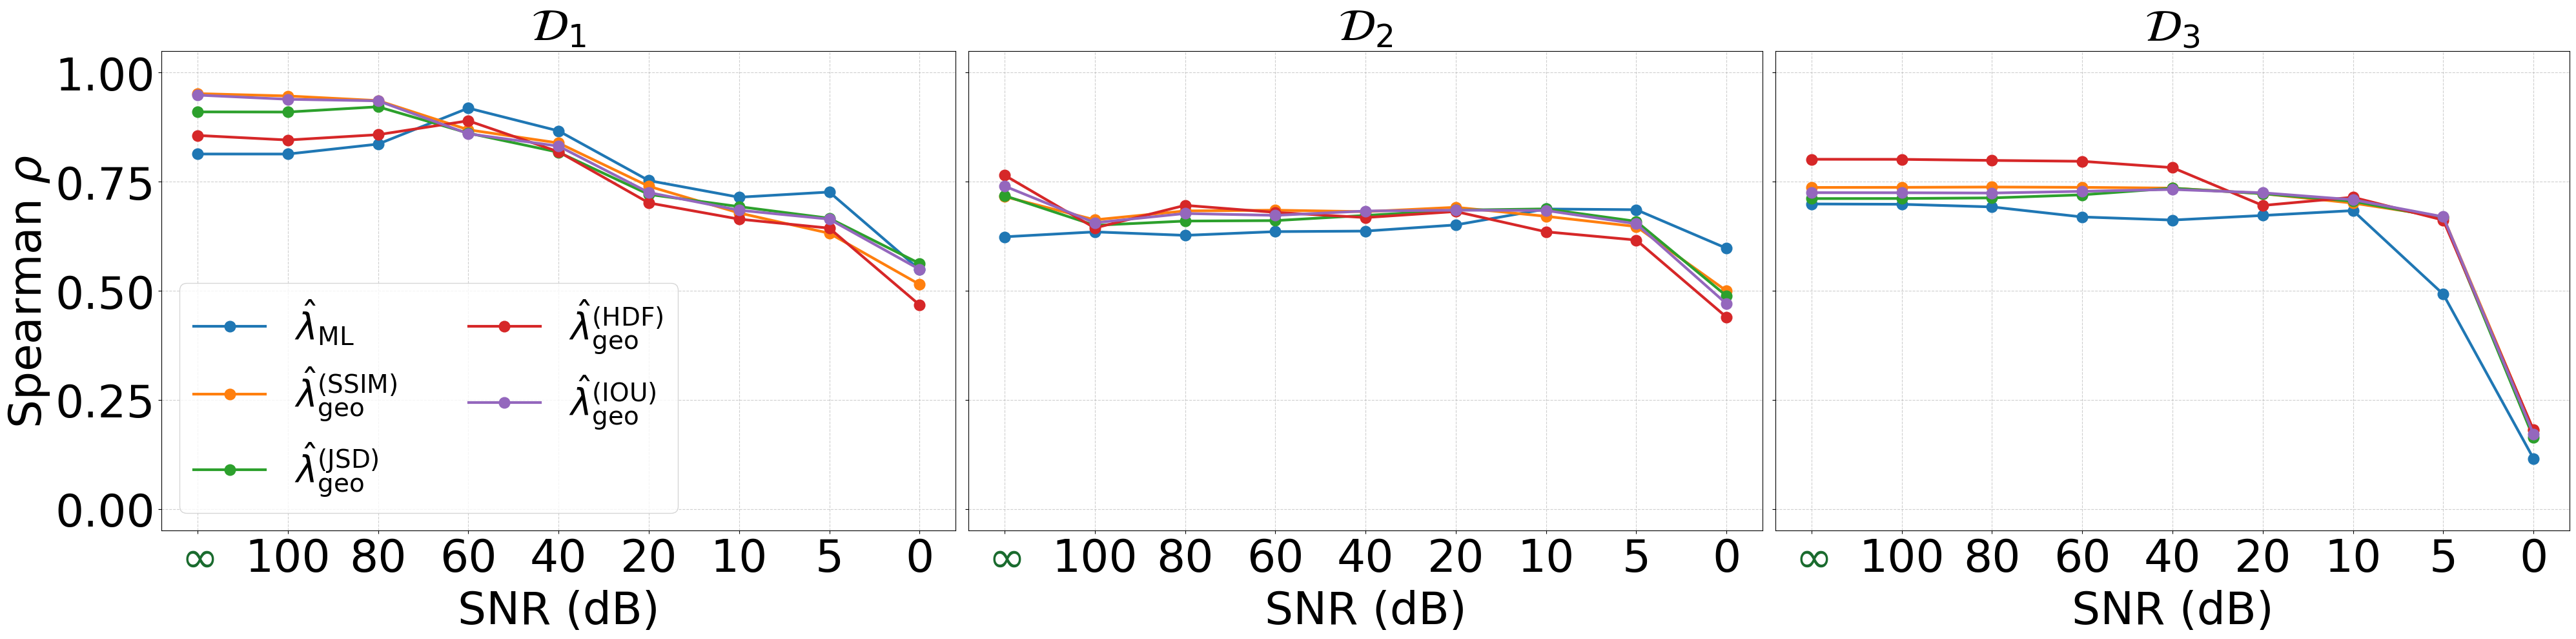

  Saved → Figure\noise_lineplot_rho.pdf


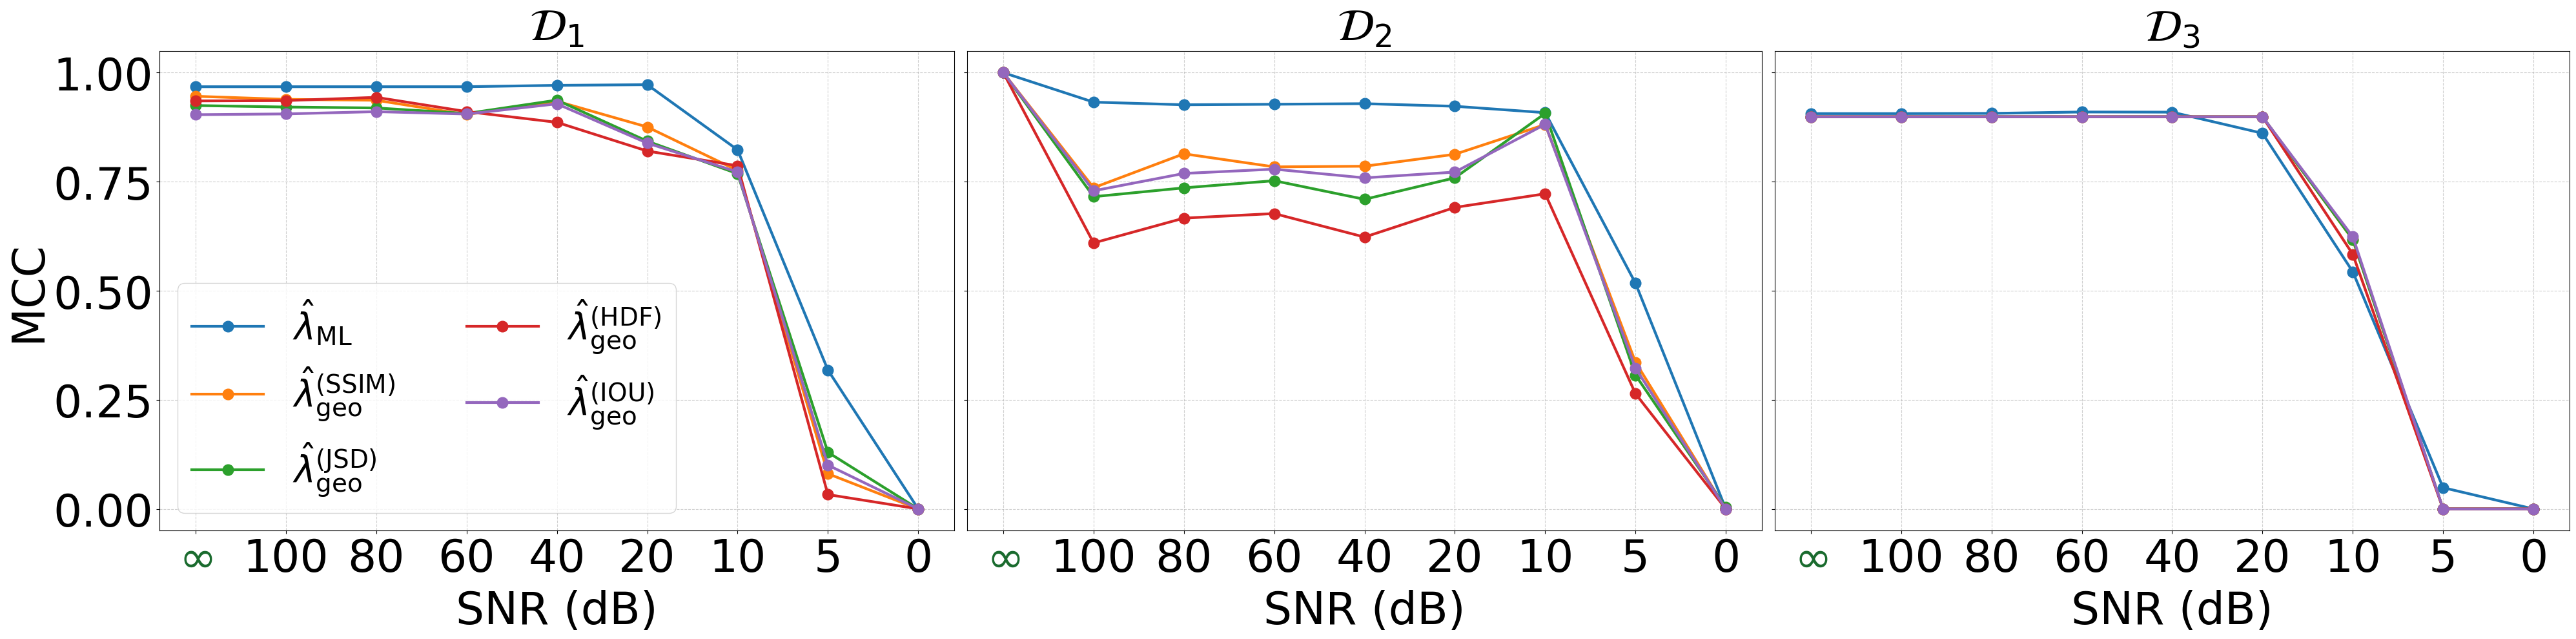

  Saved → Figure\noise_lineplot_mcc.pdf


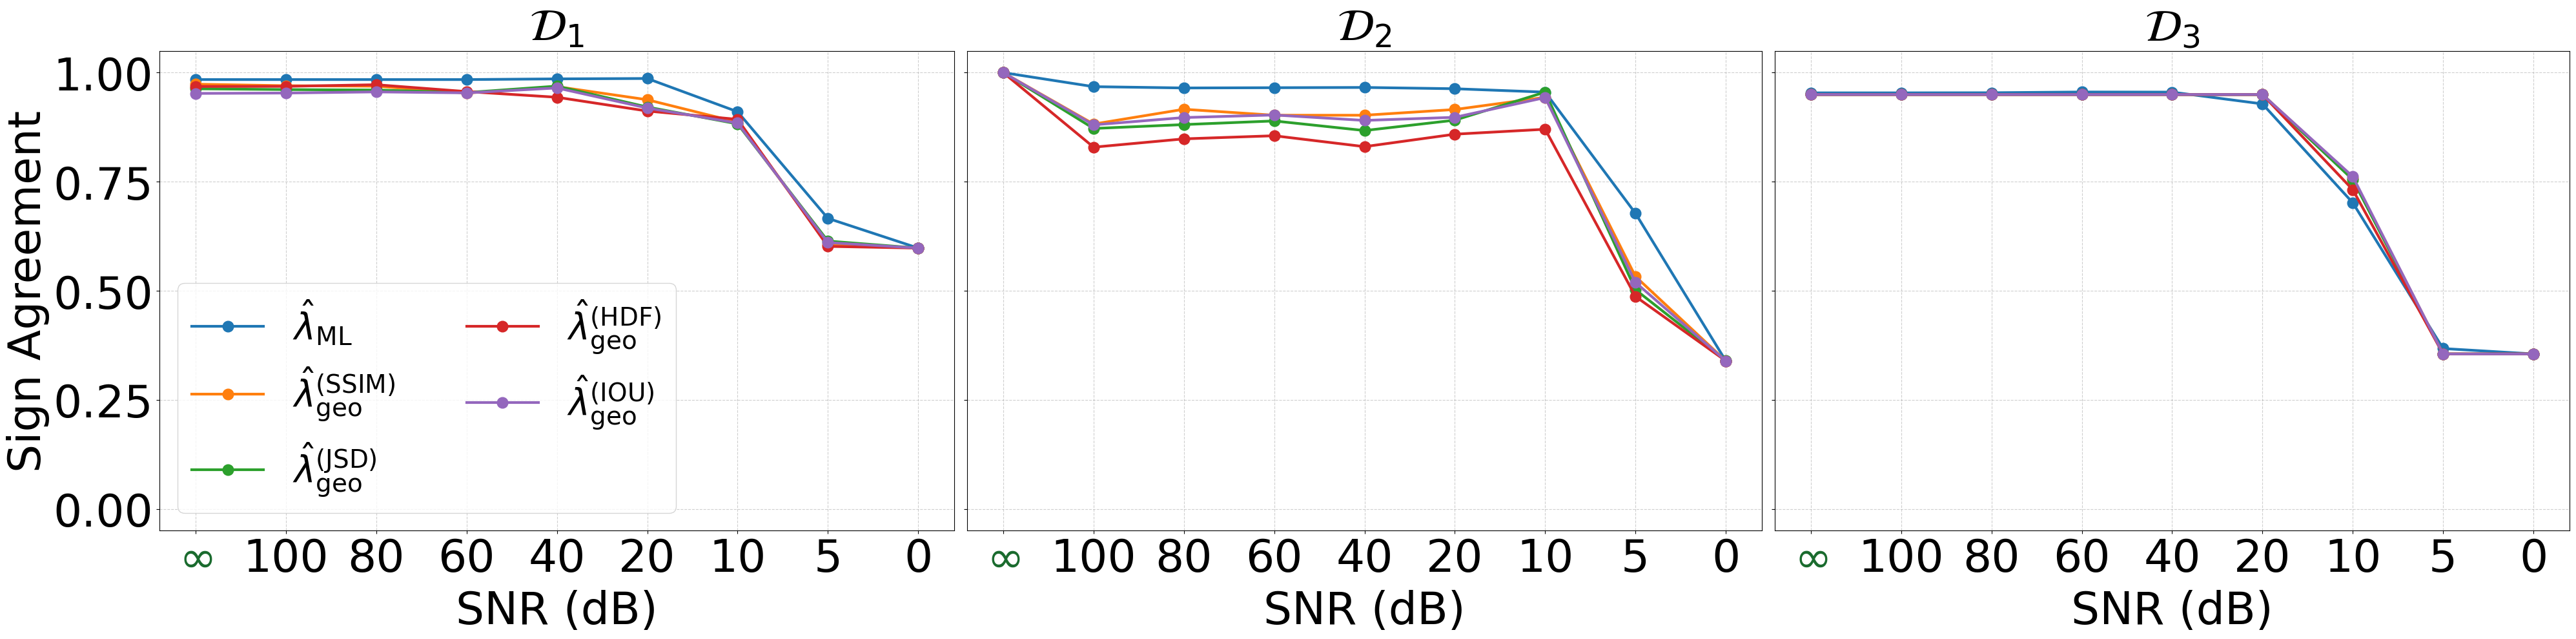

  Saved → Figure\noise_lineplot_sign_agree.pdf


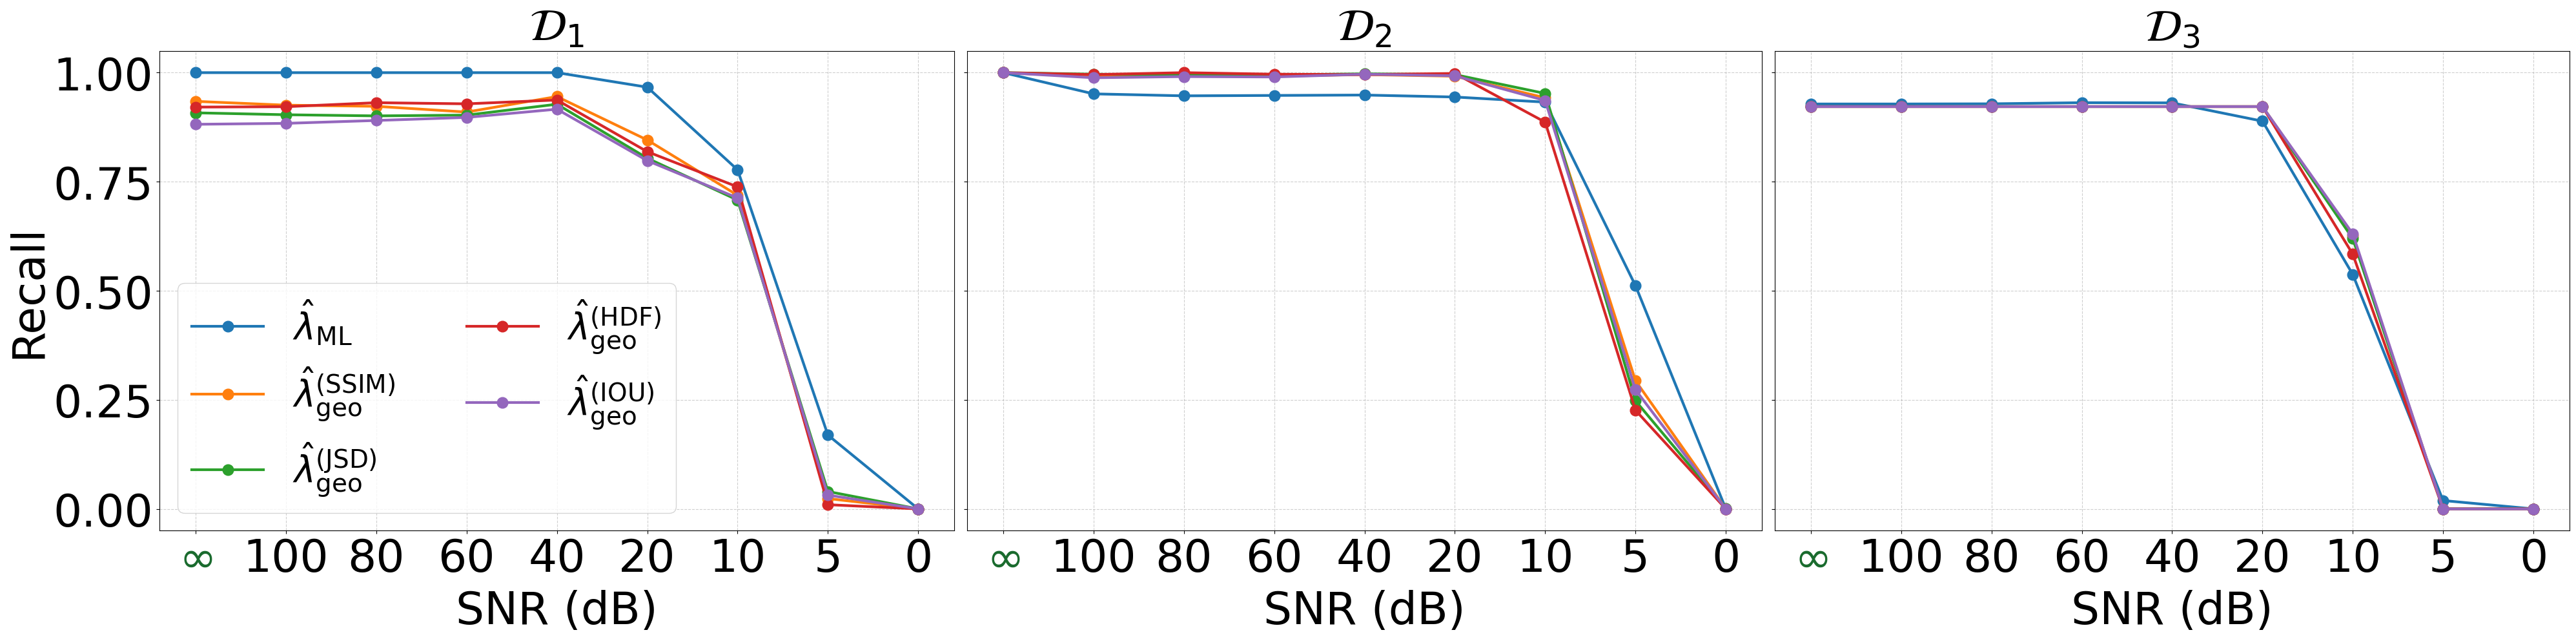

  Saved → Figure\noise_lineplot_sensitivity.pdf


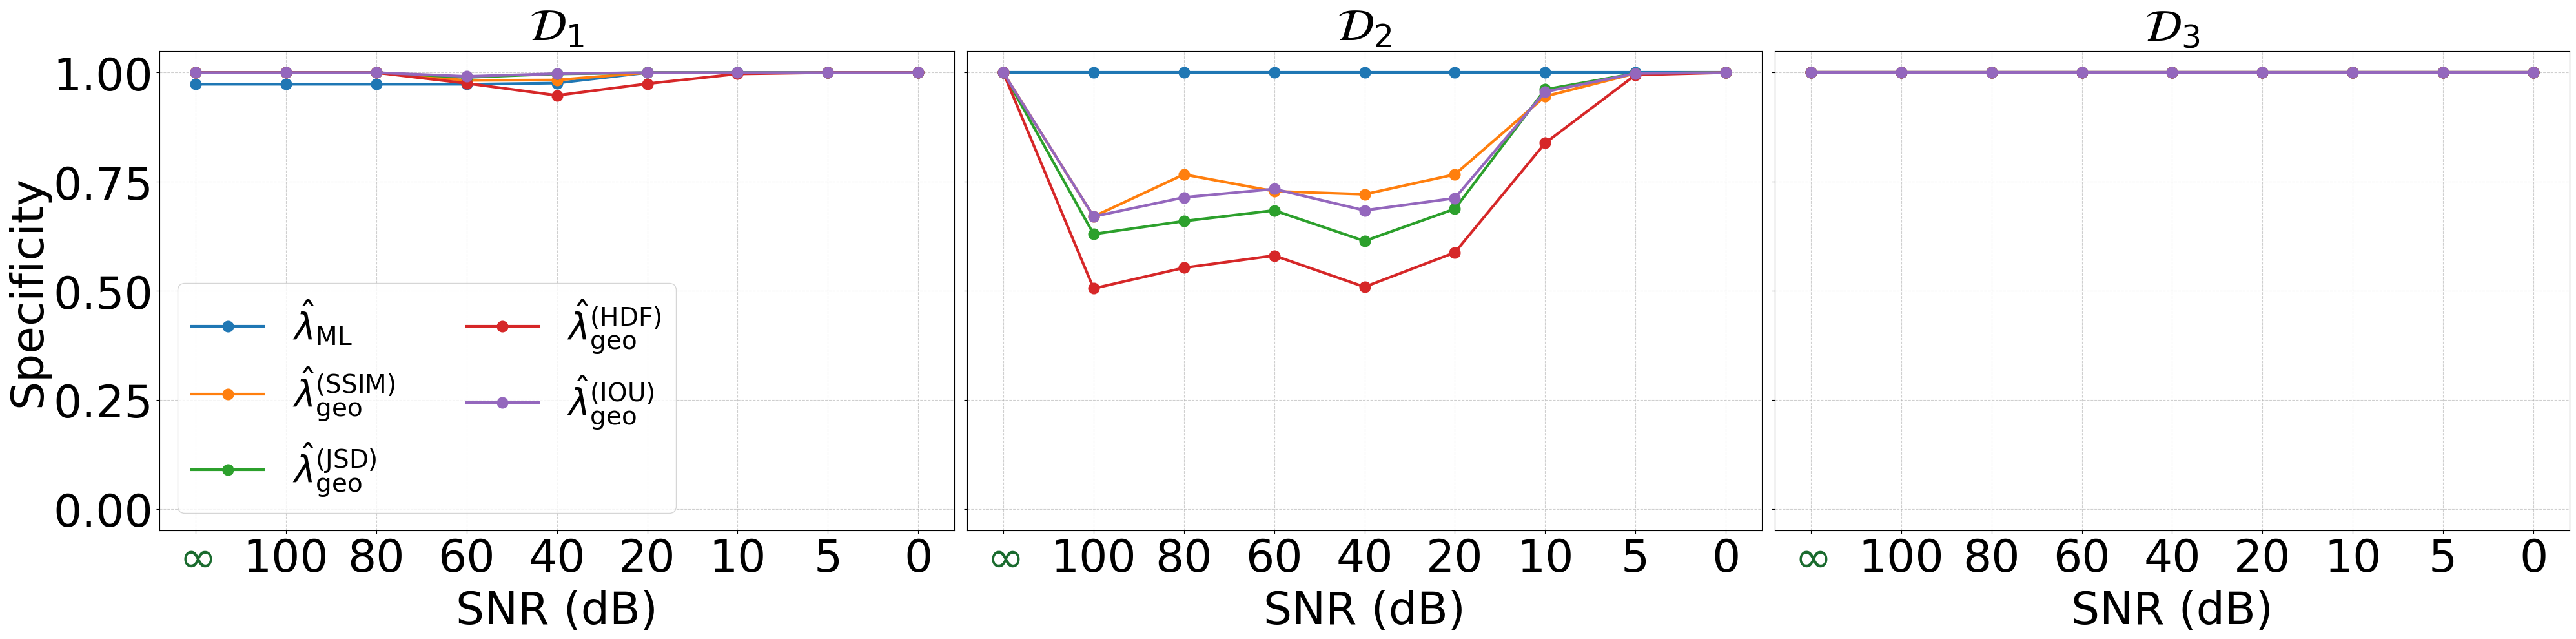

  Saved → Figure\noise_lineplot_specificity.pdf

✓ Done.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

#RESULTS_CSV = r"D:\NLD_PROJECT\ML_FTLE\publication code - Copy\data\noise_robustness\noise_robustness_results.csv" # <-- edit if needed
FIGURE_DIR = Path('Figure')
FIGURE_DIR.mkdir(exist_ok=True)

#results_df     = pd.read_csv(RESULTS_CSV)
DATASETS_AVAIL = results_df['dataset'].unique().tolist()

display_labels = {
    'ML-FTLE':   r'$\hat{\lambda}_{\mathrm{ML}}$',
    'PLSR-SSIM': r'$\hat{\lambda}_{\mathrm{geo}}^{(\mathrm{SSIM})}$',
    'PLSR-JSD':  r'$\hat{\lambda}_{\mathrm{geo}}^{(\mathrm{JSD})}$',
    'PLSR-HDF':  r'$\hat{\lambda}_{\mathrm{geo}}^{(\mathrm{HDF})}$',
    'PLSR-IOU':  r'$\hat{\lambda}_{\mathrm{geo}}^{(\mathrm{IOU})}$',
}

MARKERS = ['o', 's', '^', 'D', 'v', 'p', '*']

SNR_AVAIL = sorted(results_df['snr_db'].unique(),
                   key=lambda x: float('inf') if np.isinf(x) else -x)
CLEAN_LABEL = r'$\infty$'

LINEPLOT_CFG = [
 ('rho', 'rho_std', r'Spearman $\rho$', (-0.05, 1.05)),
 ('mcc', 'mcc_std', 'MCC', (-0.05, 1.05)),
 ('sign_agree', 'sa_std', 'Sign Agreement', (-0.05, 1.05)),
 ('sensitivity', 'sensitivity_std', 'Recall', (-0.05, 1.05)),
 ('specificity', 'specificity_std', 'Specificity', (-0.05, 1.05)),
]

col_order_snr = ([float('inf')] +
                  sorted([s for s in SNR_AVAIL if not np.isinf(s)], reverse=True))
col_labels = [CLEAN_LABEL] + [f'{int(s)}' for s in col_order_snr[1:]]
x_coords   = np.arange(len(col_labels))

# ── One figure per metric; columns = datasets ─────────────────────────────────
for metric, std_col, metric_title, (vmin_v, vmax_v) in LINEPLOT_CFG:

    n_ds = len(DATASETS_AVAIL)
    fig, axes = plt.subplots(
        nrows=1, ncols=n_ds,
        figsize=(40, 10),
        sharey=True
    )
    if n_ds == 1:
        axes = [axes]

    for ax, did in zip(axes, DATASETS_AVAIL):
        sub       = results_df[results_df['dataset'] == did]
        row_order = [r for r in display_labels.keys() if r in sub['method'].unique()]

        pivot_mean = sub.pivot_table(index='method', columns='snr_db',
                                     values=metric, aggfunc='mean')
        pivot_std  = sub.pivot_table(index='method', columns='snr_db',
                                     values=std_col, aggfunc='mean')
        pivot_mean = pivot_mean.reindex(columns=col_order_snr).reindex(row_order)
        pivot_std  = pivot_std.reindex(columns=col_order_snr).reindex(row_order)
        
        for i, method in enumerate(row_order):
            y_vals = pivot_mean.loc[method].values
            y_err  = pivot_std.loc[method].values
            ax.plot(x_coords, y_vals, marker="o",
                        #yerr=y_err,marker=MARKERS[i % len(MARKERS)],
                        label=display_labels.get(method, method),linewidth=3, markersize=12)

        n = did.split('_')[-1]
        ax.set_title(rf'$\mathcal{{D}}_{n}$', fontsize=50, fontweight='bold', pad=12)
        ax.set_xlabel('SNR (dB)', fontsize=50, labelpad=10)
        ax.set_xticks(x_coords)
        ax.set_xticklabels(col_labels, rotation=0, fontsize=50)
        ax.tick_params(axis='y', labelsize=50)
        ax.set_ylim(vmin_v, vmax_v)
        ax.grid(True, linestyle='--', alpha=0.6)
        # highlight clean (∞ dB) x-tick in green
        ax.get_xticklabels()[0].set_color('#1a6b2e')
        ax.get_xticklabels()[0].set_fontweight('bold')

        # y-label and legend only on leftmost panel
        if ax == axes[0]:
            ax.set_ylabel(metric_title, fontsize=50)
            ax.legend(fontsize=40,
                      ncol=min(len(row_order), 2),
                      loc='lower left',
                      #bbox_to_anchor=(0.0, 1.02),
                      #bbox_transform=ax.transAxes,
                      #borderaxespad=0,
                      #frameon=True
                      )

    #fig.suptitle(metric_title, fontsize=26, fontweight='bold', y=1.08)
    plt.tight_layout()

    out = FIGURE_DIR / f'Fig_8_9_10_{metric}.pdf'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'  Saved → {out}')

print('\n✓ Done.')